In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ks_2samp

# Load Parquet Files

In [3]:
real_post = pd.read_parquet("results/real/posterior_summary.parquet")
aug_post = pd.read_parquet("results/augmented/posterior_summary.parquet")

real_draws = pd.read_parquet("results/real/posterior_draws_long.parquet")
aug_draws = pd.read_parquet("results/augmented/posterior_draws_long.parquet")

real_perm = pd.read_parquet("results/real/permutation_importance.parquet")
aug_perm = pd.read_parquet("results/augmented/permutation_importance.parquet")

perm_compare = real_perm.merge(
    aug_perm,
    on="feature",
    suffixes=("_real", "_aug")
)

perm_compare = perm_compare.sort_values("mean_auroc_drop_real", ascending=False)
perm_compare.head()
real_metrics = pd.read_parquet("results/real/metrics.parquet")
real_roc = pd.read_parquet("results/real/roc_points.parquet")
real_certainty = pd.read_parquet("results/real/posterior_prediction_summary.parquet")

aug_metrics = pd.read_parquet("results/augmented/metrics.parquet")
aug_roc = pd.read_parquet("results/augmented/roc_points.parquet")
aug_certainty = pd.read_parquet("results/augmented/posterior_prediction_summary.parquet")

metrics_df = pd.concat([real_metrics, aug_metrics], ignore_index=True)
roc_df = pd.concat([real_roc, aug_roc], ignore_index=True)
certainty_df = pd.concat([real_certainty, aug_certainty], ignore_index=True)

In [4]:
metrics_df

,model,accuracy,precision,recall,f1_score,auroc
0,real_only,0.982456,1.0,0.952381,0.97561,0.993386
1,real_plus_synthetic,1.000000,1.0,1.000000,1.00000,1.000000


# Plot Performance Metrics

In [5]:
certainty_summary = (
    certainty_df
    .groupby("model")[["sd_prob", "interval_width", "entropy"]]
    .mean()
    .reset_index()
)

certainty_cols = ["sd_prob", "interval_width", "entropy"]

certainty_baseline = certainty_summary.loc[
    certainty_summary["model"] == "real_only",
    certainty_cols
].iloc[0]

certainty_vs_real = certainty_summary.copy()
for col in certainty_cols:
    certainty_vs_real[f"{col}_diff_vs_real"] = certainty_vs_real[col] - certainty_baseline[col]

certainty_vs_real

,model,sd_prob,interval_width,entropy,sd_prob_diff_vs_real,interval_width_diff_vs_real,entropy_diff_vs_real
0,real_only,0.029138,0.096026,0.066504,0.00000,0.000000,0.000000
1,real_plus_synthetic,0.020988,0.072852,0.075996,-0.00815,-0.023174,0.009491


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

wide_sd = certainty_df.pivot(
    index="row_id",
    columns="model",
    values="sd_prob"
).dropna()

wide_sd["diff"] = wide_sd["real_plus_synthetic"] - wide_sd["real_only"]
wide_sd.head()

model,real_only,real_plus_synthetic,diff
row_id,,,
1,5.878164e-08,0.000001,0.000001
2,3.387661e-05,0.000169,0.000135
3,3.047055e-02,0.047225,0.016755
4,5.104659e-03,0.004832,-0.000273
5,4.466797e-03,0.016386,0.011920


In [7]:
t_stat, p_val = ttest_rel(
    wide_sd["real_plus_synthetic"],
    wide_sd["real_only"]
)

print("paired t-test")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("mean difference:", wide_sd["diff"].mean())

paired t-test
t-statistic: -1.0304121851395023
p-value: 0.30724648820944295
mean difference: -0.008150084590276132


In [8]:
w_stat, w_p = wilcoxon(
    wide_sd["real_plus_synthetic"],
    wide_sd["real_only"]
)

print("wilcoxon signed-rank test")
print("statistic:", w_stat)
print("p-value:", w_p)

wilcoxon signed-rank test
statistic: 615.0
p-value: 0.09287727800263469


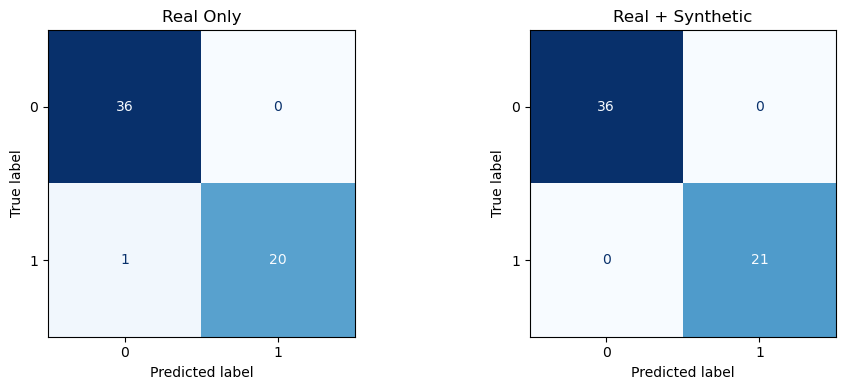

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

real_preds = pd.read_parquet("results/real/predictions.parquet")
aug_preds = pd.read_parquet("results/augmented/predictions.parquet")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_real = confusion_matrix(real_preds["y_true"], real_preds["y_pred"])
cm_aug = confusion_matrix(aug_preds["y_true"], aug_preds["y_pred"])

ConfusionMatrixDisplay(cm_real).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Real Only")

ConfusionMatrixDisplay(cm_aug).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Real + Synthetic")

plt.tight_layout()
plt.show()

In [ ]:
# summary of boundary for real and augmented model
certainty_df["boundary_distance"] = (certainty_df["mean_prob"] - 0.5).abs()
boundary_summary = (
    certainty_df
    .groupby("model")[["boundary_distance"]]
    .mean()
    .reset_index()
)

boundary_summary

,model,boundary_distance
0,real_only,0.473929
1,real_plus_synthetic,0.473725


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

wide_bd = certainty_df.pivot(
    index="row_id",
    columns="model",
    values="boundary_distance"
).dropna()

wide_bd["diff"] = wide_bd["real_plus_synthetic"] - wide_bd["real_only"]

print("mean difference:", wide_bd["diff"].mean())

t_stat, p_val = ttest_rel(
    wide_bd["real_plus_synthetic"],
    wide_bd["real_only"]
)
print("paired t-test p-value:", p_val)

w_stat, w_p = wilcoxon(
    wide_bd["real_plus_synthetic"],
    wide_bd["real_only"]
)
print("wilcoxon p-value:", w_p)

mean difference: -0.00020389782560924146
paired t-test p-value: 0.9817492598290307
wilcoxon p-value: 0.0021921962000410844


# Feature Importance

In [ ]:
real_post[["term", "posterior_mean", "posterior_sd", "cv_signed", "cv_abs"]].head(10)

,term,posterior_mean,posterior_sd,cv_signed,cv_abs
0,concavity1,3.898627,0.695498,0.178396,0.178396
1,texture3,3.260903,0.630392,0.193318,0.193318
2,area2,5.569772,1.199377,0.215337,0.215337
3,concavity2,-2.767541,0.650905,-0.235192,0.235192
4,concavity3,2.817947,0.750885,0.266465,0.266465
5,area3,2.883711,0.819860,0.284307,0.284307
6,radius2,4.117910,1.277220,0.310162,0.310162
7,texture2,-1.709132,0.582529,-0.340834,0.340834
8,compactness2,-2.696927,0.949312,-0.351998,0.351998
9,concave_points2,3.123193,1.308185,0.418861,0.418861


In [ ]:
aug_post[["term", "posterior_mean", "posterior_sd", "cv_signed", "cv_abs"]].head(10)

,term,posterior_mean,posterior_sd,cv_signed,cv_abs
0,Intercept,2.866575,0.409914,0.142998,0.142998
1,fractal_dimension2,-2.200879,0.482493,-0.219227,0.219227
2,perimeter3,2.648279,0.644575,0.243394,0.243394
3,area2,2.320974,0.665313,0.286652,0.286652
4,symmetry1,0.939342,0.269600,0.287010,0.287010
5,texture3,1.225409,0.360583,0.294255,0.294255
6,area3,3.289195,1.029552,0.313010,0.313010
7,radius2,2.192054,0.691716,0.315556,0.315556
8,symmetry2,-1.023529,0.337705,-0.329942,0.329942
9,concave_points3,1.443925,0.571733,0.395957,0.395957


In [ ]:
real_cvs = real_post['cv_abs']
aug_post = aug_post['cv_abs']

ks_2samp(real_cvs, aug_post)

KstestResult(statistic=0.12903225806451613, pvalue=0.9634297148886908, statistic_location=2.1913956437092232, statistic_sign=-1)